# Dataset (https://www.kaggle.com/datasets/kazanova/sentiment140)

* https://www.youtube.com/watch?v=mY-lIkjrvzI&list=PL049bGjkT7dIARLPrxvA4-tbEcg6k0UDX&index=123

In [1]:
patience=12
epochs=999

In [2]:
from google.colab import drive
drive.mount('/gdrive')

Drive already mounted at /gdrive; to attempt to forcibly remount, call drive.mount("/gdrive", force_remount=True).


In [3]:
folder = '/gdrive/MyDrive/data/'

In [4]:
!ls '/gdrive/MyDrive/data/'

births.csv	   glove.6B.100d.txt  Synthetic_Financial_datasets_log.csv.zip
births_github.csv  glove.6B.200d.txt  tweets.csv
decades.csv	   glove.6B.300d.txt  WASTE_COURT.zip
exemple.txt	   glove.6B.50d.txt   WASTE.zip


In [5]:
import pandas as pd

In [6]:
df = pd.read_csv(folder + "tweets.csv", encoding="latin", header=None)

In [7]:
df.head()

,0,1,2,3,4,5
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [8]:
df = df.iloc[:,[0, 5]]

In [9]:
df.head()

,0,5
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,is upset that he can't update his Facebook by ...
2,0,@Kenichan I dived many times for the ball. Man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."


In [10]:
df.columns = ['sentiment', 'tweet']

In [11]:
df.head()

,sentiment,tweet
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,is upset that he can't update his Facebook by ...
2,0,@Kenichan I dived many times for the ball. Man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."


In [12]:
df['sentiment'].value_counts()

,count
sentiment,
0,800000
4,800000


In [13]:
sents = {0:"negatif", 4:"positif"}

In [14]:
sents[0]

'negatif'

In [15]:
df['sentiment'] = df['sentiment'].replace(sents)

In [16]:
df.head()

,sentiment,tweet
0,negatif,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,negatif,is upset that he can't update his Facebook by ...
2,negatif,@Kenichan I dived many times for the ball. Man...
3,negatif,my whole body feels itchy and like its on fire
4,negatif,"@nationwideclass no, it's not behaving at all...."


In [17]:
df.sample(10)

,sentiment,tweet
504539,negatif,Giants are losing tonight...
106311,negatif,Can't belive that hes all I think about.. :/ i...
1357754,positif,the hubby is on a man-cation so let the girly ...
406681,negatif,And it is closed
828228,positif,"@michaelgrainger it is, indeed"
1466607,positif,@omergertel heh sending too many messages on ...
1260375,positif,So ready to go back to work!! What a weekend
905384,positif,@KalvinClein hey! thanks for following how is...
1239869,positif,"@RobotDeathSquad I hear you 'Bot, I had to be ..."
1317993,positif,my heart jumps out of excitement...someone's f...


# Preprocessing

In [18]:
import re # regex

In [19]:
text_cleaning_regex = r"@\S+|https?:\S+|http?:\S+|[^A-Za-z0-9]+"

In [20]:
import nltk # Natural Langage ToolKit

In [21]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [22]:
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

In [23]:
english_stopwords = stopwords.words('english')

In [24]:
english_stopwords

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [25]:
stemmer = SnowballStemmer('english')

In [26]:
stemmer.stem('cats'),stemmer.stem('available')

('cat', 'avail')

In [27]:
def preprocess(text):

  # les mentions les liens et tout ce qui n'est pas alphanumérique
  text_cleaning_regex = r"@\S+|https?:\S+|http?:\S+|[^A-Za-z0-9]+"
  text = re.sub(text_cleaning_regex, " ", str(text).lower().strip())

  tokens = []
  # stopwords and stem
  for word in text.split(" "):
    if word not in english_stopwords:
      word_stem = stemmer.stem(word)
      tokens.append(word_stem)

  cleaned_text = " ".join(tokens).strip()


  return cleaned_text

In [28]:
preprocess("@kevin_degila Hello, I was wondering when your course on deep learning would be available ? http://kevindegila.com")

'hello wonder cours deep learn would avail'

In [29]:
df['text'] = df['tweet'].apply(preprocess)

In [30]:
df.head()

,sentiment,tweet,text
0,negatif,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",awww bummer shoulda got david carr third day
1,negatif,is upset that he can't update his Facebook by ...,upset updat facebook text might cri result sch...
2,negatif,@Kenichan I dived many times for the ball. Man...,dive mani time ball manag save 50 rest go bound
3,negatif,my whole body feels itchy and like its on fire,whole bodi feel itchi like fire
4,negatif,"@nationwideclass no, it's not behaving at all....",behav mad see


# Train test split

In [31]:
from sklearn.model_selection import train_test_split

In [32]:
train_data, test_data = train_test_split(df, test_size=0.2, stratify=df['sentiment'], random_state=42)

In [33]:
len(train_data)

1280000

In [34]:
len(test_data)

320000

In [35]:
test_data['sentiment'].value_counts()

,count
sentiment,
negatif,160000
positif,160000


In [36]:
def length(text):
  return len(text.split(' '))

In [37]:
df['len'] = df['text'].apply(length)

In [38]:
df['len'].describe()

,len
count,1.600000e+06
mean,7.229460e+00
std,4.053380e+00
min,1.000000e+00
25%,4.000000e+00
50%,7.000000e+00
75%,1.000000e+01
max,5.000000e+01


In [39]:
df['len'].min(), df['len'].max(), df['len'].mean(), df['len'].median(), df['len'].std()

(1, 50, np.float64(7.22946), 7.0, 4.053380179192111)

Écart type (4.05) : L'écart type d'environ 4.05 indique la dispersion des longueurs de tweets autour de la moyenne. Un écart type de 4.05 par rapport à une moyenne de 7.23 suggère qu'il y a une variation modérée dans les longueurs de tweets. La plupart des tweets auront une longueur comprise dans une certaine plage autour de la moyenne (par exemple, environ 68 % des tweets auront une longueur comprise entre 7.23 - 4.05 et 7.23 + 4.05, soit environ 3.18 et 11.28 mots, en supposant une distribution normale, bien que la distribution montrée par le displot ne soit pas parfaitement normale).
En résumé, les tweets dans cet ensemble de données sont relativement courts, avec une longueur moyenne d'environ 7 mots et une variation modérée autour de cette moyenne. La plupart des tweets se situent dans une fourchette de longueur assez restreinte.


d'où 'sort' ce 68% ?
Le "68%" vient de la règle empirique, aussi appelée règle des 68-95-99.7 ou règle des trois sigmas. Cette règle statistique s'applique aux distributions normales (en forme de cloche). Elle stipule que pour une distribution normale :

Environ 68 % des données se situent à moins d'un écart type de la moyenne.
Environ 95 % des données se situent à moins de deux écarts types de la moyenne.
Environ 99.7 % des données se situent à moins de trois écarts types de la moyenne.
Dans mon explication précédente, j'ai mentionné le 68 % en faisant l'hypothèse d'une distribution normale pour donner une idée générale de la dispersion. Cependant, comme je l'ai également noté, la distribution des longueurs de tweets montrée par le graphique de distribution (displot) n'est pas parfaitement normale. Par conséquent, le pourcentage réel de tweets se situant à un écart type de la moyenne peut être légèrement différent de 68 %. C'était une approximation pour illustrer la signification de l'écart type.

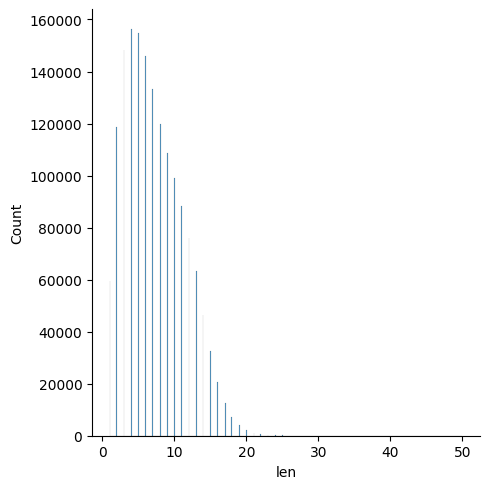

In [40]:
import seaborn as sns
sns.displot(df['len'])

# Tokenization and text to sequences

In [41]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [42]:
vocab_size = 70000
maxlen = 15
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(train_data['text'])
word_index = tokenizer.word_index

training_sequences = tokenizer.texts_to_sequences(train_data['text'])
training_padded = pad_sequences(training_sequences, padding="post", maxlen=maxlen, truncating="post")
test_sequences = tokenizer.texts_to_sequences(test_data['text'])
test_padded = pad_sequences(test_sequences, padding="post", maxlen=maxlen, truncating="post")

KeyboardInterrupt: 

In [ ]:
training_padded

# Label Encoder

In [ ]:
train_data['sentiment']

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
encoder = LabelEncoder()
training_labels = encoder.fit_transform(train_data['sentiment'])

In [ ]:
training_labels

In [ ]:
test_data.shape

In [ ]:
test_labels = encoder.transform(test_data['sentiment'])

In [ ]:
training_labels.shape

In [ ]:
training_labels = training_labels.reshape(-1, 1)
test_labels = test_labels.reshape(-1, 1)

In [ ]:
test_labels.shape

# Modeling

In [ ]:
import tensorflow as tf

In [ ]:
import numpy as np

In [ ]:
np.power(70000, 1/4) # Racine qatrième

In [ ]:
embedding_dim = 16
model = tf.keras.models.Sequential(
    [
        tf.keras.layers.Embedding(vocab_size, embedding_dim),
        tf.keras.layers.GlobalAveragePooling1D(),
        tf.keras.layers.Dense(8, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ]
)

model.compile(loss='binary_crossentropy', optimizer="adam", metrics=['accuracy'])
model_ckp = tf.keras.callbacks.ModelCheckpoint(filepath="best_model.h5",
                            monitor="val_accuracy",
                            mode="max",
                            save_best_only=True)
stop = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=patience, restore_best_weights=True)
h = model.fit(training_padded, training_labels, epochs=epochs, batch_size=512,
              validation_data=(test_padded, test_labels),
              callbacks=[model_ckp, stop])

In [ ]:
import matplotlib.pyplot as plt


def plot_graphs(history, string):
    plt.plot(history.history[string])
    plt.plot(history.history['val_'+string])
    plt.xlabel("Epochs")
    plt.ylabel(string)
    plt.legend([string, 'val_'+string])
    plt.grid()
    plt.show()

    h=history
    best_val_accuracy = max(h.history["val_accuracy"])
    print(
        f"The best validation accuracy achieved was: {max(h.history['val_accuracy']):.4f} at epoch {h.history['val_accuracy'].index(best_val_accuracy) + 1}"
    )

In [ ]:
plot_graphs(h, 'accuracy')
plot_graphs(h, "loss")

# Recurrent Neural Networks
(ou Looping NN)

In [ ]:
# "J'étais content, maintenant je suis enervé" negatif
# "J'étais enervé, maintenant je suis content" positif

In [ ]:
embedding_dim = 16
model = tf.keras.models.Sequential(
    [
        tf.keras.layers.Embedding(vocab_size, embedding_dim),
        tf.keras.layers.SimpleRNN(10),
        tf.keras.layers.Dense(8, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ]
)

model.compile(loss='binary_crossentropy', optimizer="adam", metrics=['accuracy'])
model_ckp = tf.keras.callbacks.ModelCheckpoint(filepath="best_model.h5",
                            monitor="val_accuracy",
                            mode="max",
                            save_best_only=True)
stop = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=patience, restore_best_weights=True)

In [ ]:
model.summary()

In [ ]:
h = model.fit(training_padded, training_labels, epochs=epochs, batch_size=512,
              validation_data=(test_padded, test_labels),
              callbacks=[model_ckp, stop])

In [ ]:
plot_graphs(h, 'accuracy')
plot_graphs(h, "loss")

In [ ]:
embedding_dim = 16
model = tf.keras.models.Sequential(
    [
        tf.keras.layers.Embedding(vocab_size, embedding_dim),
        tf.keras.layers.SimpleRNN(10, return_sequences=True),
        tf.keras.layers.SimpleRNN(10, return_sequences=True),
        tf.keras.layers.SimpleRNN(10),
        tf.keras.layers.Dense(8, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ]
)

model.compile(loss='binary_crossentropy', optimizer="adam", metrics=['accuracy'])
model_ckp = tf.keras.callbacks.ModelCheckpoint(filepath="best_model.h5",
                            monitor="val_accuracy",
                            mode="max",
                            save_best_only=True)
stop = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=patience, restore_best_weights=True)

# LSTM

In [ ]:
# Je vis en , J'ai vécu dans différentes villes jusque-là, sauf la capital PARIS

In [ ]:
adam = tf.keras.optimizers.Adam()

In [ ]:
embedding_dim = 16
model = tf.keras.models.Sequential(
    [
        tf.keras.layers.Embedding(vocab_size, embedding_dim),
        tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(16, return_sequences=True, dropout=0.25)),
        tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(16)),
        tf.keras.layers.Dense(8, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ]
)

model.compile(loss='binary_crossentropy', optimizer="adam", metrics=['accuracy'])
model_ckp = tf.keras.callbacks.ModelCheckpoint(filepath="best_model.h5",
                            monitor="val_accuracy",
                            mode="max",
                            save_best_only=True)
stop = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=patience, restore_best_weights=True)

In [ ]:
model.summary()

In [ ]:
h = model.fit(training_padded, training_labels, epochs=epochs, batch_size=512,
              validation_data=(test_padded, test_labels),
              callbacks=[model_ckp, stop])

In [ ]:
plot_graphs(h, 'accuracy')
plot_graphs(h, "loss")

# Transfert Learning

In [ ]:
glove_file = folder + "glove.6B.50d.txt"

In [ ]:
glove_file

In [ ]:
glove_embeddings = {}

In [ ]:
with open(glove_file) as f:
  for line in f:

    values = line.split(" ")
    word = values[0]
    vector = np.asarray(values[1:], dtype="float32")
    glove_embeddings[word] = vector


In [ ]:
glove_embeddings

In [ ]:
glove_embeddings['the']

In [ ]:
len(glove_embeddings)

In [ ]:
words = word_index.keys()

In [ ]:
i = 0
for word in words:
  if glove_embeddings.get(word) is not None:
    i = i + 1
print(i)

In [ ]:
len(words)

In [ ]:
embedding_matrix = np.zeros((vocab_size, 50))

In [ ]:
embedding_matrix.shape

In [ ]:
embedding_matrix[0]

In [ ]:
len(word_index)

In [ ]:
for word, i in word_index.items():
  if i > vocab_size -1:
    break
  embedding_vector = glove_embeddings.get(word)
  if embedding_vector is not None:
    embedding_matrix[i] = embedding_vector


In [ ]:
embedding_matrix[5]

In [ ]:
embedding_dim = 16
model = tf.keras.models.Sequential(
    [
        tf.keras.layers.Embedding(vocab_size, 50, weights=[embedding_matrix], trainable=False),
        tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(16, return_sequences=True, dropout=0.25)),
        tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(16)),
        tf.keras.layers.Dense(8, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ]
)

model.compile(loss='binary_crossentropy', optimizer="adam", metrics=['accuracy'])
model_ckp = tf.keras.callbacks.ModelCheckpoint(filepath="best_model.h5",
                            monitor="val_accuracy",
                            mode="max",
                            save_best_only=True)
stop = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=patience, restore_best_weights=True)

In [ ]:
h = model.fit(training_padded, training_labels, epochs=epochs, batch_size=512,
              validation_data=(test_padded, test_labels),
              callbacks=[model_ckp, stop])

In [ ]:
plot_graphs(h, 'accuracy')
plot_graphs(h, "loss")